In [1]:
# mount your google drive to load files directly from there
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
#import sys
#sys.path.append('/content/drive/My Drive/work/teaching/2025 Advanced Deep Learning/')

In [3]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
#DATA_PATH = '/content/drive/My Drive/work/teaching/2025 Advanced Deep Learning/data/galah4/'

In [4]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
#import helper

In [5]:
spectra = np.load(f"data/galah4/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"data/galah4/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [6]:
# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

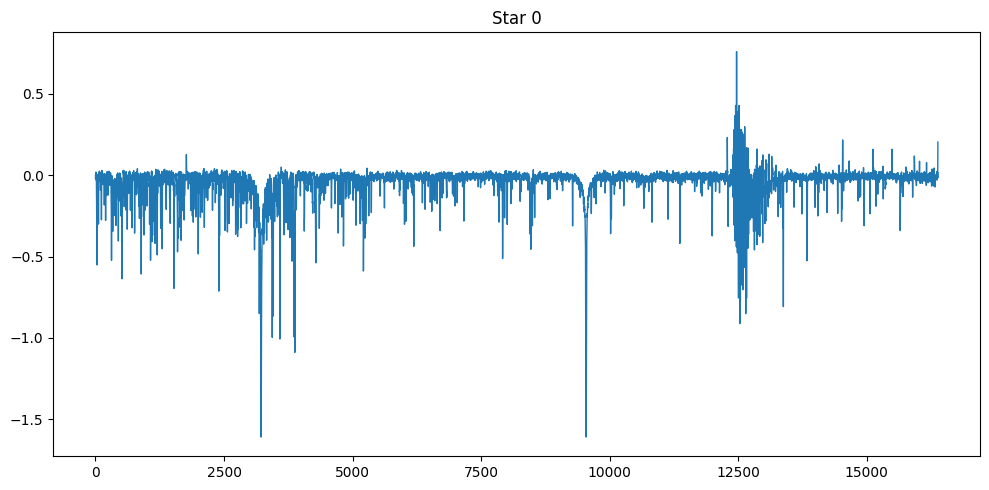

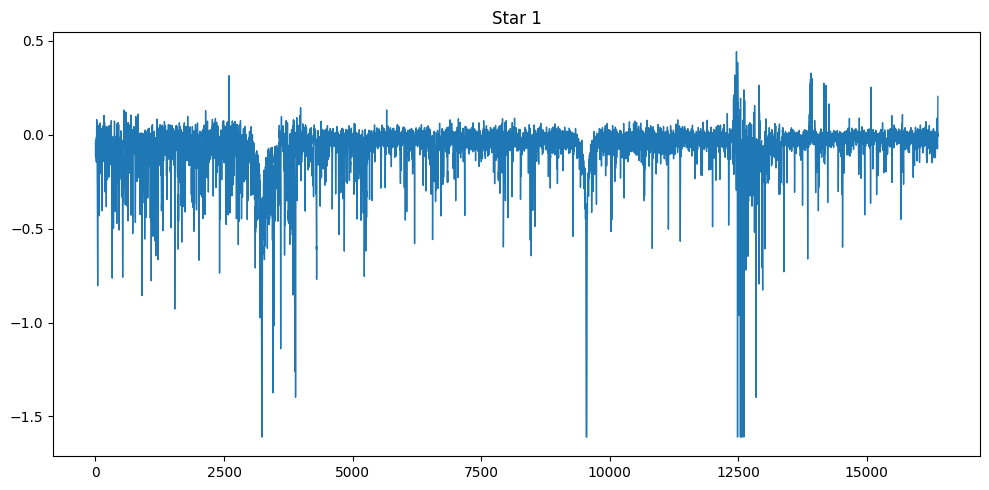

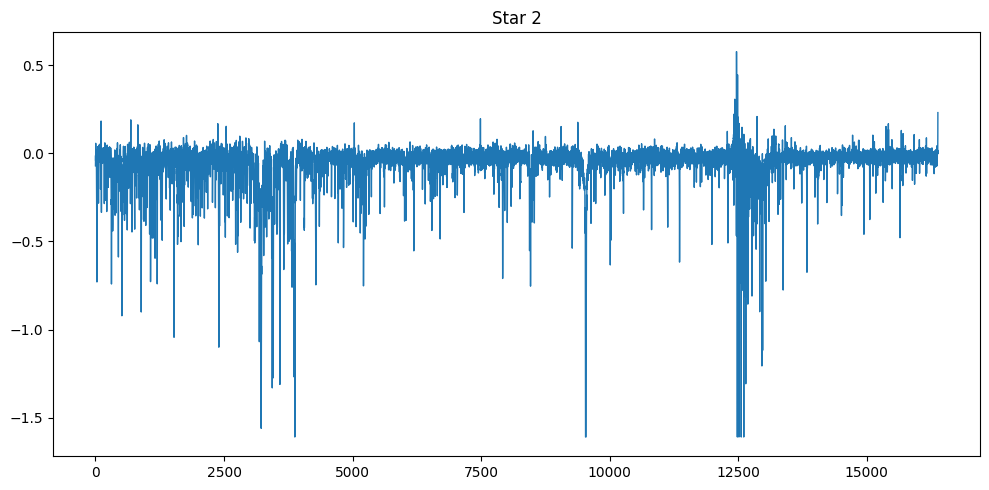

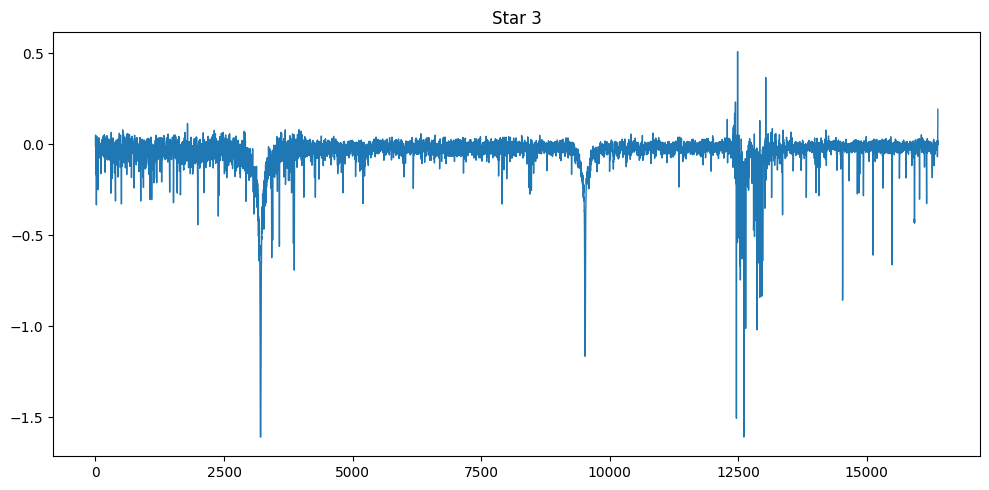

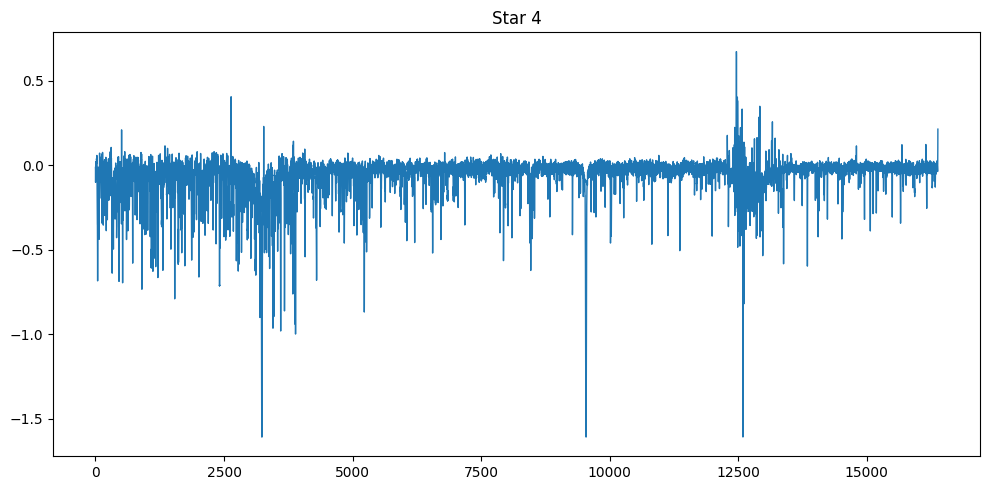

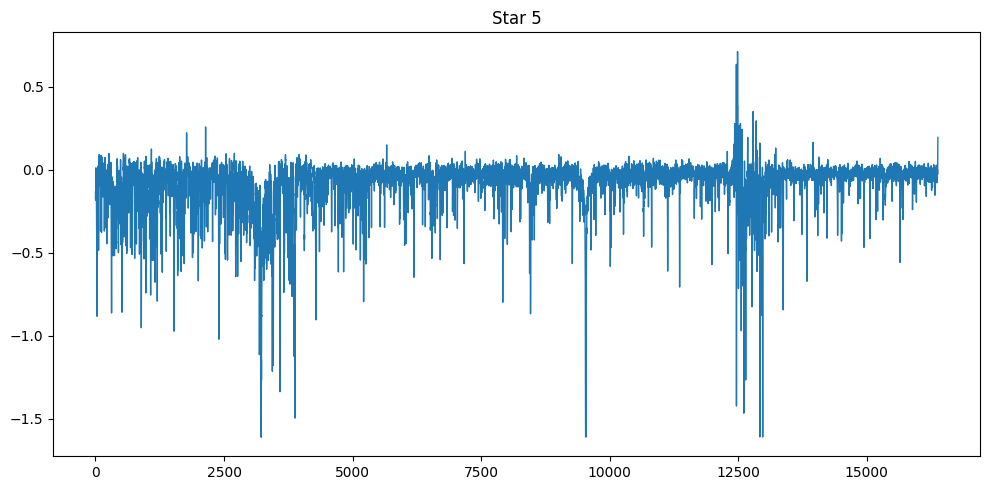

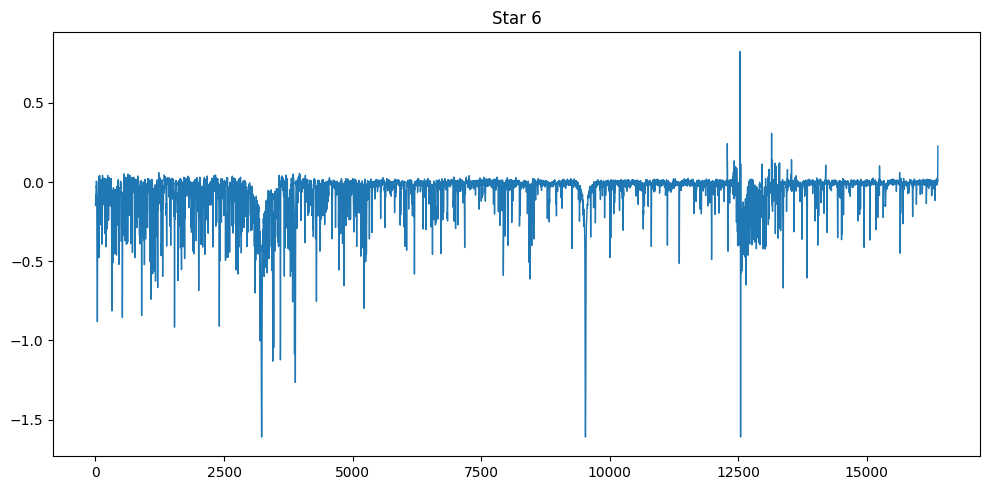

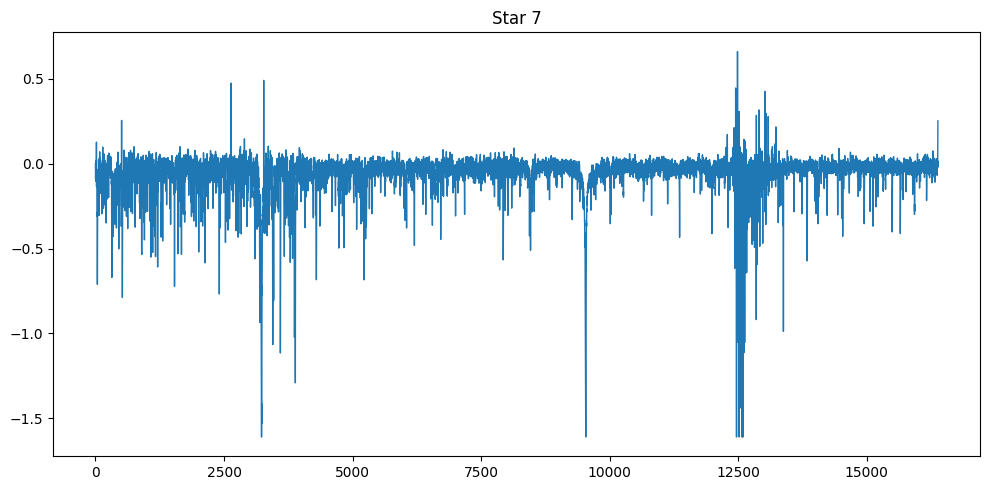

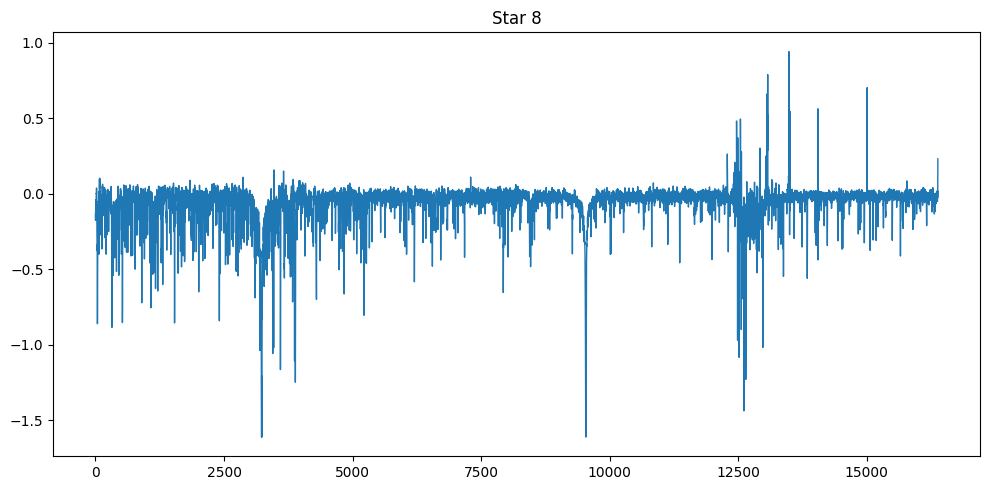

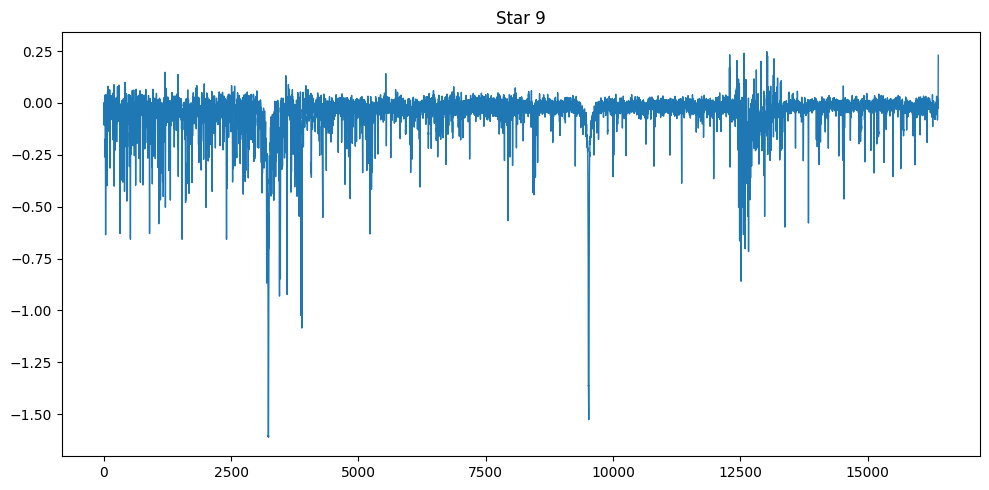

In [7]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()

In [8]:
# Prepare the dataset
# Standardize the labels to ensure balanced loss across all three parameters
y_mean = np.mean(labels, axis=0)
y_std = np.std(labels, axis=0)
labels_normalized = (labels - y_mean) / y_std

# Convert numpy arrays to PyTorch tensors
X = torch.tensor(spectra, dtype=torch.float32).unsqueeze(1) # shape: (N, 1, spectra_length)
y = torch.tensor(labels_normalized, dtype=torch.float32) # shape: (N, 3)

# Split into train and validation sets
dataset = TensorDataset(X, y)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {train_size}, Val size: {val_size}")
print(f"Input shape: {X.shape}, Output shape: {y.shape}")

Train size: 7131, Val size: 1783
Input shape: torch.Size([8914, 1, 16384]), Output shape: torch.Size([8914, 3])


### I used CNN generated from AI but I reduce the layer because of runtime

In [9]:
# Define the Vanilla CNN Model
class VanillaCNN(nn.Module):
    def __init__(self, input_length, num_classes=3):
        super(VanillaCNN, self).__init__()
        
        # Standard 1D CNN blocks: Conv1d -> ReLU -> MaxPool1d
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            #nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),
            #nn.ReLU(),
            #nn.MaxPool1d(kernel_size=2),
        )
        
        # Dummy forward pass to find the flattened size
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_length)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.numel()
        
        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

#device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

model = VanillaCNN(input_length=spectra_length, num_classes=n_labels).to(device)
summary(model, (1, spectra_length), device=device.type)

Using device: cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 16, 16384]              96
              ReLU-2            [-1, 16, 16384]               0
         MaxPool1d-3             [-1, 16, 8192]               0
            Conv1d-4             [-1, 32, 8192]           2,592
              ReLU-5             [-1, 32, 8192]               0
         MaxPool1d-6             [-1, 32, 4096]               0
            Linear-7                  [-1, 128]      16,777,344
              ReLU-8                  [-1, 128]               0
            Linear-9                    [-1, 3]             387
Total params: 16,780,419
Trainable params: 16,780,419
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/backward pass size (MB): 10.00
Params size (MB): 64.01
Estimated Total Size (MB): 74.08
----------------

In [10]:
# Training Loop
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    start_time = time.time()
    
    # Training phase
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_train_loss = running_loss / train_size
    train_losses.append(epoch_train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = val_loss / val_size
    val_losses.append(epoch_val_loss)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} | Time: {epoch_time:.2f}s | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Starting training...
Epoch 1/10 | Time: 156.42s | Train Loss: 1.3224 | Val Loss: 0.4698
Epoch 2/10 | Time: 154.55s | Train Loss: 0.3158 | Val Loss: 0.2265
Epoch 3/10 | Time: 156.91s | Train Loss: 0.1828 | Val Loss: 0.1506
Epoch 4/10 | Time: 156.69s | Train Loss: 0.1405 | Val Loss: 0.1137
Epoch 5/10 | Time: 154.60s | Train Loss: 0.1049 | Val Loss: 0.0980
Epoch 6/10 | Time: 152.38s | Train Loss: 0.0885 | Val Loss: 0.0873
Epoch 7/10 | Time: 153.55s | Train Loss: 0.0762 | Val Loss: 0.0827
Epoch 8/10 | Time: 155.62s | Train Loss: 0.0676 | Val Loss: 0.0734
Epoch 9/10 | Time: 157.76s | Train Loss: 0.0571 | Val Loss: 0.0732
Epoch 10/10 | Time: 151.30s | Train Loss: 0.0504 | Val Loss: 0.0710


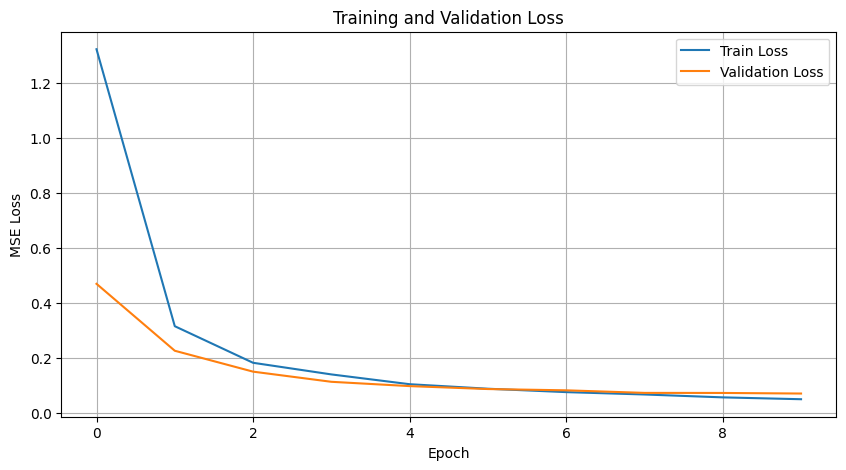

In [11]:
# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

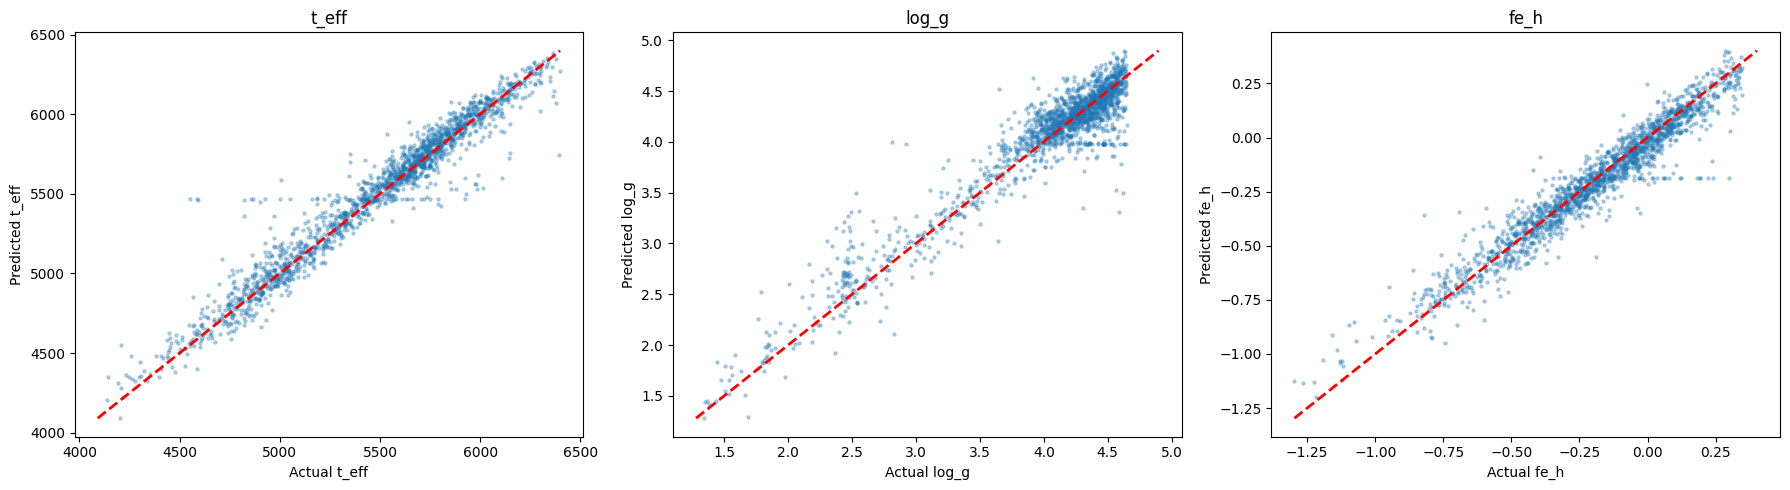

In [12]:
# Evaluation
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Reverse standardization to plot in original physical units
all_preds_orig = all_preds * y_std + y_mean
all_targets_orig = all_targets * y_std + y_mean

# Plot actual vs predicted for each label
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, label_name in enumerate(labelNames):
    axes[i].scatter(all_targets_orig[:, i], all_preds_orig[:, i], alpha=0.3, s=5)
    
    # Perfect prediction line
    min_val = min(all_targets_orig[:, i].min(), all_preds_orig[:, i].min())
    max_val = max(all_targets_orig[:, i].max(), all_preds_orig[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[i].set_xlabel(f'Actual {label_name}')
    axes[i].set_ylabel(f'Predicted {label_name}')
    axes[i].set_title(f'{label_name}')

plt.tight_layout()
plt.show()

## Predicting Parameters and Uncertainties (Gaussian) using Negative Log-Likelihood

- Same network but return two outputs (mean and variance)

In [21]:
class VanillaCNNUncertainty(nn.Module):
    def __init__(self, input_length, num_classes=3):
        super(VanillaCNNUncertainty, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            nn.Conv1d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
            
            #nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            #nn.ReLU(),
            #nn.MaxPool1d(kernel_size=2, stride=2)
        )
        
        # Calculate the size of the flattened features
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, input_length)
            dummy_output = self.features(dummy_input)
            self.flattened_size = dummy_output.numel()
        
        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 128),
            nn.ReLU(),
            # Output mean and log_variance for each class (3 classes * 2 = 6 outputs)
            nn.Linear(128, num_classes * 2) 
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        
        # Split output into mean and log_variance
        mean, log_var = torch.chunk(x, 2, dim=1)
        return mean, log_var

model_unc = VanillaCNNUncertainty(input_length=spectra_length, num_classes=n_labels).to(device)

In [ ]:
# 2. Define Gaussian Negative Log-Likelihood Loss Function
def nll_loss(mean, log_var, target):
    loss = 0.5 * (log_var + (target - mean)**2 * torch.exp(-log_var))
    return loss

In [ ]:
# Put the model in evaluation mode to disable dropout/batchnorm updates
model_unc.eval()

# Initialize empty lists to collect predictions and targets
all_preds_mean = []
all_preds_log_var = []
all_targets_unc = []
nll_loss = []

# Disable gradient calculation for evaluation to save memory and compute
with torch.no_grad():
    for inputs, targets in val_loader:
        
        # Forward pass: get predicted mean and log variance
        mean, log_var = model_unc(inputs)
        
        loss_matrix = 0.5 * (log_var + (targets - mean)**2 * torch.exp(-log_var))

        mean_loss = loss_matrix.mean(dim=1)

        # Move the tensors back to CPU, convert to numpy, and append to our lists
        all_preds_mean.append(mean.cpu().numpy())
        all_preds_log_var.append(log_var.cpu().numpy())
        all_targets_unc.append(targets.cpu().numpy())
        nll_loss.extend(mean_loss.cpu().numpy())

# Vertically stack the lists of batches into flat, unified NumPy arrays
all_preds_mean = np.vstack(all_preds_mean)
all_preds_log_var = np.vstack(all_preds_log_var)
all_targets_unc = np.vstack(all_targets_unc)


## This is validation loss distribution from negative log-likelihood per star

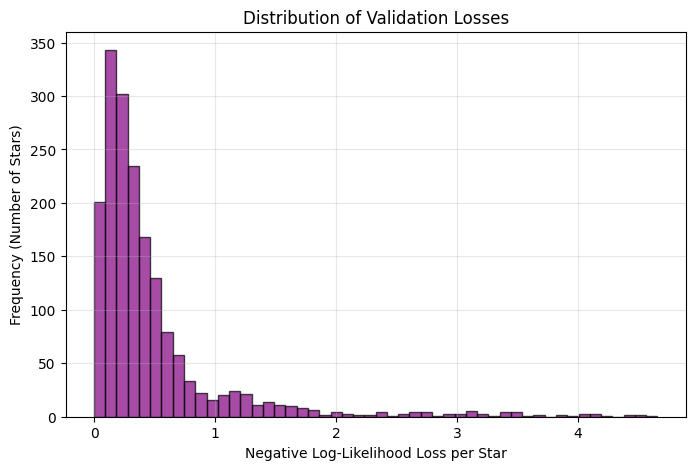

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(nll_loss, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel('Negative Log-Likelihood Loss per Star')
plt.ylabel('Frequency (Number of Stars)')
plt.title('Distribution of Validation Losses')
plt.grid(True, alpha=0.3)
plt.show()

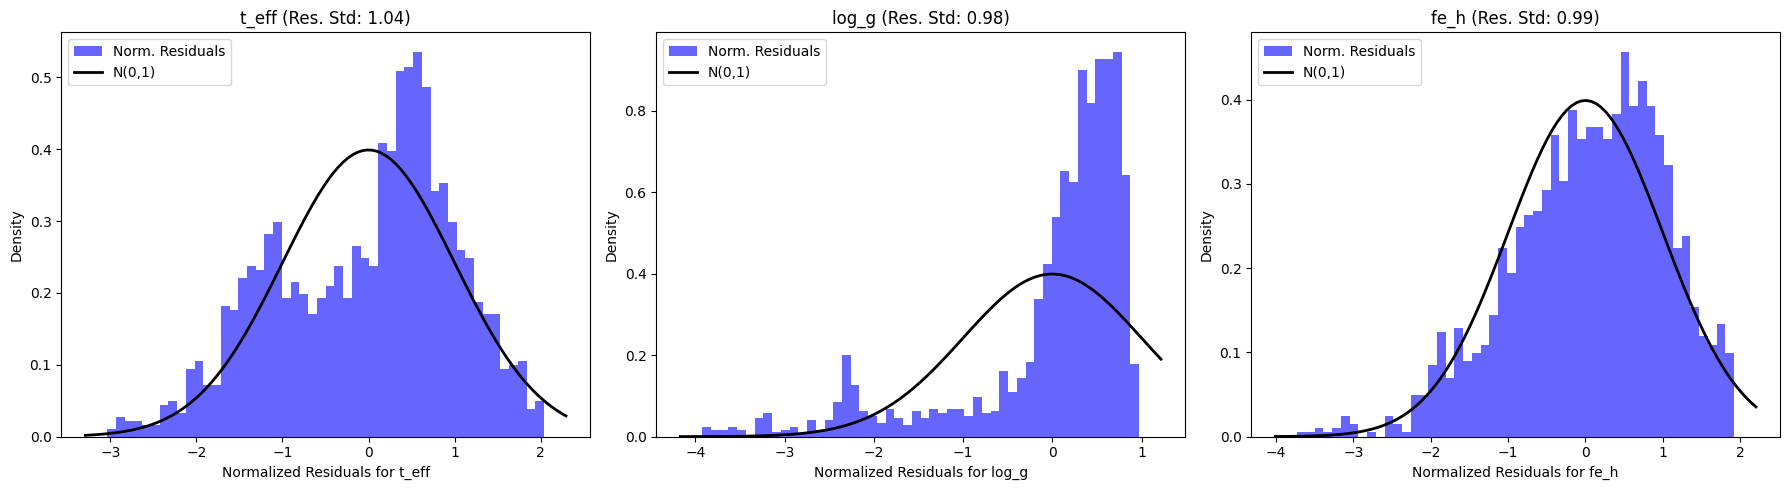

In [ ]:
from scipy.stats import norm
    
# 3. Quantify how well uncertainties were determined by plotting the distribution of normalized residuals
# Normalized Residual = (Target - Mean) / Standard_Deviation
# If uncertainties are perfectly calibrated, this should follow a Standard Normal Distribution N(0, 1)
normalized_residuals = (all_targets_unc - all_preds_mean) / np.exp(0.5 * all_preds_log_var)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, label_name in enumerate(labelNames):
    data = normalized_residuals[:, i]
    
    # Histogram of normalized residuals
    axes[i].hist(data, bins=50, density=True, alpha=0.6, color='b', label='Norm. Residuals')
    
    # Plot standard normal curve N(0, 1) for comparison
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, 0, 1)
    axes[i].plot(x, p, 'k', linewidth=2, label='N(0,1)')
    
    # Calculate actual standard deviation of normalized residuals
    actual_std = np.std(data)
    
    axes[i].set_xlabel(f'Normalized Residuals for {label_name}')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{label_name} (Res. Std: {actual_std:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()